# Polymarket Markets Exploration

This notebook loads `data/processed/all_markets.jsonl` -- the deduplicated, always-current
view of every market Polymarket has ever had (built by `src/data_collection/merge_data.py`:
one row per market id, keeping whichever version has the newest `updatedAt`) -- and looks
for patterns worth knowing before building anything on top of this data.

A couple of things worth keeping in mind while reading the numbers below:
- For what each field means and whether it's worth analyzing, see `docs/market_fields.md` --
  we lean on that instead of re-deriving field meaning here.
- id-based analysis (missing ids, id density, etc.) isn't included here -- it's not
  informative for this data (Polymarket ids aren't a clean sequential population count).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

REPO_ROOT = Path.cwd().parent
ALL_MARKETS_PATH = REPO_ROOT / "data" / "processed" / "all_markets.jsonl"


## 1. Loading the data

One market per line, with a lot of fields that are just internal Polymarket plumbing
(fee config, oracle bookkeeping -- see `docs/market_fields.md` §5). We pull out only the
fields with analytical value and keep everything in one flat table, instead of holding
the full nested JSON in memory.

In [2]:
def parse_market(m):
    """Flattens one raw market record down to the fields we actually use for analysis."""
    events = m.get("events") or []
    event = events[0] if events else {}
    series_list = event.get("series") or []
    series = series_list[0] if series_list else {}

    return {
        "id": m.get("id"),
        "question": m.get("question"),
        "createdAt": m.get("createdAt"),
        "updatedAt": m.get("updatedAt"),
        "startDate": m.get("startDate"),
        "endDate": m.get("endDate"),
        "closedTime": m.get("closedTime"),
        "active": m.get("active"),
        "closed": m.get("closed"),
        "archived": m.get("archived"),
        "volumeNum": m.get("volumeNum"),
        "liquidityNum": m.get("liquidityNum"),
        "volume24hr": m.get("volume24hr"),
        "volume1wk": m.get("volume1wk"),
        "volume1mo": m.get("volume1mo"),
        "competitive": m.get("competitive"),
        "spread": m.get("spread"),
        "lastTradePrice": m.get("lastTradePrice"),
        "outcomePrices": m.get("outcomePrices"),
        "outcomes": m.get("outcomes"),
        "oneDayPriceChange": m.get("oneDayPriceChange"),
        "commentCount": event.get("commentCount"),
        "recurrence": series.get("recurrence"),
        "ticker": series.get("ticker"),
    }


def load_jsonl(path):
    """Streams the file line by line -- only ever holds the raw JSON of a single
    line at a time, not the whole file."""
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(parse_market(json.loads(line)))
    return pd.DataFrame(rows)


In [3]:
all_df = load_jsonl(ALL_MARKETS_PATH)
print(f"{len(all_df):,} markets")
all_df.head()


1,698,867 markets


,id,question,createdAt,updatedAt,startDate,endDate,closedTime,active,closed,archived,volumeNum,liquidityNum,volume24hr,volume1wk,volume1mo,competitive,spread,lastTradePrice,outcomePrices,outcomes,oneDayPriceChange,commentCount,recurrence,ticker
0,2842657,"Ethereum above 1,830 on July 8, 3AM ET?",2026-07-08T05:40:12.038879Z,2026-07-09T06:03:44.858797Z,2026-07-08T05:42:25.032882Z,2026-07-08T07:00:00Z,2026-07-08 07:12:14+00,True,True,False,115.000,NaN,NaN,NaN,NaN,NaN,0.001,NaN,"[""0"", ""1""]","[""Yes"", ""No""]",NaN,0.0,hourly,ethereum-multi-strikes-hourly
1,2842656,"Ethereum above 1,820 on July 8, 3AM ET?",2026-07-08T05:40:11.855619Z,2026-07-09T06:03:44.858797Z,2026-07-08T05:42:48.482372Z,2026-07-08T07:00:00Z,2026-07-08 07:12:14+00,True,True,False,115.000,NaN,NaN,NaN,NaN,NaN,0.001,NaN,"[""0"", ""1""]","[""Yes"", ""No""]",NaN,0.0,hourly,ethereum-multi-strikes-hourly
2,2842655,"Ethereum above 1,810 on July 8, 3AM ET?",2026-07-08T05:40:11.626589Z,2026-07-09T06:05:43.909336Z,2026-07-08T05:42:21.940914Z,2026-07-08T07:00:00Z,2026-07-08 07:12:14+00,True,True,False,115.000,NaN,NaN,NaN,NaN,NaN,0.001,NaN,"[""0"", ""1""]","[""Yes"", ""No""]",NaN,0.0,hourly,ethereum-multi-strikes-hourly
3,2842654,"Ethereum above 1,800 on July 8, 3AM ET?",2026-07-08T05:40:11.453154Z,2026-07-09T06:03:44.858797Z,2026-07-08T05:42:51.814833Z,2026-07-08T07:00:00Z,2026-07-08 07:12:14+00,True,True,False,115.000,NaN,NaN,NaN,NaN,NaN,0.001,NaN,"[""0"", ""1""]","[""Yes"", ""No""]",NaN,0.0,hourly,ethereum-multi-strikes-hourly
4,2842653,"Ethereum above 1,790 on July 8, 3AM ET?",2026-07-08T05:40:11.248585Z,2026-07-09T06:51:43.265156Z,2026-07-08T05:42:33.443805Z,2026-07-08T07:00:00Z,2026-07-08 07:12:14+00,True,True,False,114.993,NaN,NaN,NaN,NaN,NaN,0.001,NaN,"[""0"", ""1""]","[""Yes"", ""No""]",NaN,0.0,hourly,ethereum-multi-strikes-hourly


A few columns need a bit of cleanup before they're usable: dates arrive as strings,
and prices/outcomes are JSON-encoded *inside* the JSON. We do that once, in one place.

In [4]:
def add_derived_columns(df):
    df = df.copy()
    for col in ("createdAt", "updatedAt", "startDate", "endDate", "closedTime"):
        df[col] = pd.to_datetime(df[col], utc=True, errors="coerce", format="ISO8601")
    for col in ("volumeNum", "liquidityNum", "volume24hr", "volume1wk", "volume1mo",
                "competitive", "spread", "lastTradePrice", "oneDayPriceChange"):
        df[col] = pd.to_numeric(df[col], errors="coerce")
    # "bitcoin-multi-strikes-hourly" -> "bitcoin" -- the coin id lives at the series level, not the market
    df["coin"] = df["ticker"].str.split("-").str[0]
    return df


all_df = add_derived_columns(all_df)
all_df.dtypes


id                                   str
question                             str
createdAt            datetime64[us, UTC]
updatedAt            datetime64[us, UTC]
startDate            datetime64[us, UTC]
endDate              datetime64[us, UTC]
closedTime           datetime64[us, UTC]
active                              bool
closed                              bool
archived                            bool
volumeNum                        float64
liquidityNum                     float64
volume24hr                       float64
volume1wk                        float64
volume1mo                        float64
competitive                      float64
spread                           float64
lastTradePrice                   float64
outcomePrices                        str
outcomes                             str
oneDayPriceChange                float64
commentCount                     float64
recurrence                           str
ticker                               str
coin            

## 2. Markets created per month, since the beginning

How Polymarket's market-creation volume has grown over time.

C:\Users\Erulan\AppData\Local\Temp\ipykernel_8676\3580652776.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda d: d["createdAt"].dt.to_period("M").dt.to_timestamp())


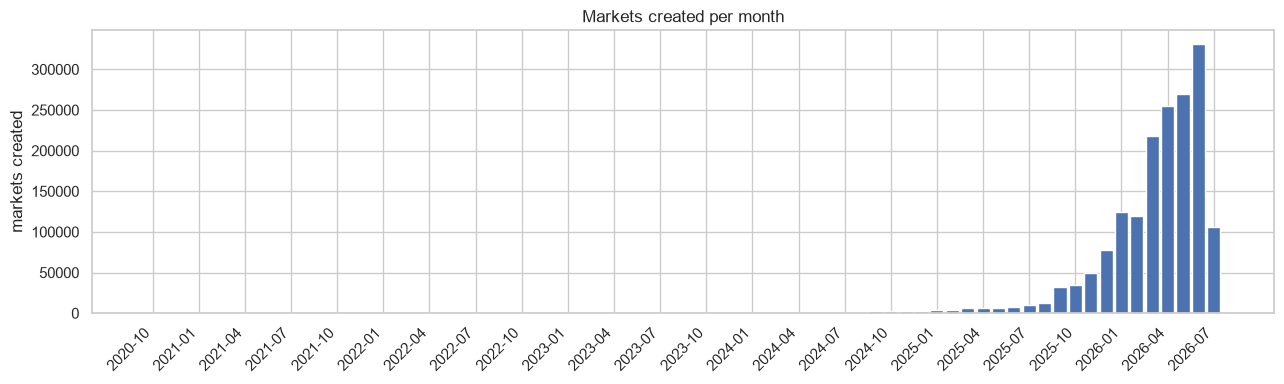

Busiest month so far: 2026-06 with 331,277 markets created
Total months with any activity: 70


In [5]:
monthly = (
    all_df.dropna(subset=["createdAt"])
          .assign(month=lambda d: d["createdAt"].dt.to_period("M").dt.to_timestamp())
          .groupby("month").size()
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(range(len(monthly)), monthly.values, color="#4C72B0", width=0.85)
tick_positions = range(0, len(monthly), 3)   # one label per quarter, otherwise they overlap
ax.set_xticks(list(tick_positions))
ax.set_xticklabels([monthly.index[i].strftime("%Y-%m") for i in tick_positions], rotation=45, ha="right")
ax.set_title("Markets created per month")
ax.set_ylabel("markets created")
plt.tight_layout()
plt.show()

print(f"Busiest month so far: {monthly.idxmax():%Y-%m} with {monthly.max():,} markets created")
print(f"Total months with any activity: {len(monthly)}")


## 3. Volume & liquidity -- how much actual trading happens?

Most markets barely get any action; a small number carry most of the volume. That's a
classic long-tail shape, so we look at it on a log scale instead of a linear one.

1,284,877 / 1,698,867 markets (75.6%) have any trading volume at all


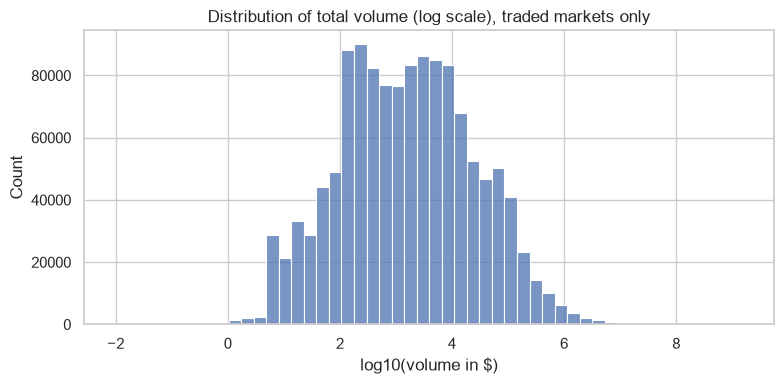

count    1.284877e+06
mean     7.112357e+04
std      2.198906e+06
min      1.000000e-02
25%      2.023900e+02
50%      1.560314e+03
75%      1.097791e+04
max      1.531479e+09
Name: volumeNum, dtype: float64

In [6]:
traded = all_df[all_df["volumeNum"] > 0]
print(f"{len(traded):,} / {len(all_df):,} markets ({len(traded) / len(all_df):.1%}) have any trading volume at all")

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(np.log10(traded["volumeNum"]), bins=50, ax=ax)
ax.set_title("Distribution of total volume (log scale), traded markets only")
ax.set_xlabel("log10(volume in $)")
plt.tight_layout()
plt.show()

traded["volumeNum"].describe()


## 4. How markets resolve -- which side wins?

`outcomePrices` only gets populated once a market closes/resolves, and it's the ground
truth of what actually happened (`["0", "1"]` means the second outcome won). We use it
here just to see the overall split, not to build a trading signal.

In [7]:
resolved = all_df[all_df["closed"] & all_df["outcomePrices"].notna() & all_df["outcomes"].notna()].copy()

prices_parsed = resolved["outcomePrices"].map(json.loads)
outcomes_parsed = resolved["outcomes"].map(json.loads)

def pick_winner(prices, outcomes):
    try:
        return outcomes[prices.index("1")]
    except (ValueError, IndexError):
        return None

resolved["winner"] = [pick_winner(p, o) for p, o in zip(prices_parsed, outcomes_parsed)]

print(f"{len(resolved):,} / {len(all_df):,} markets are resolved with a clear winner")
resolved["winner"].value_counts(normalize=True).head(10)


1,655,350 / 1,698,867 markets are resolved with a clear winner


winner
No           0.252151
Down         0.158757
Up           0.158462
Under        0.098635
Yes          0.093722
Over         0.074721
Even         0.005332
Under 2.5    0.005097
Odd          0.004963
Over 2.5     0.002697
Name: proportion, dtype: float64

## 5. Recurrence -- hourly, daily, or one-off?

The `recurrence` field (from the market's series) tells us the cadence a market repeats
on -- e.g. the hourly BTC/ETH strike markets vs a one-off event market.

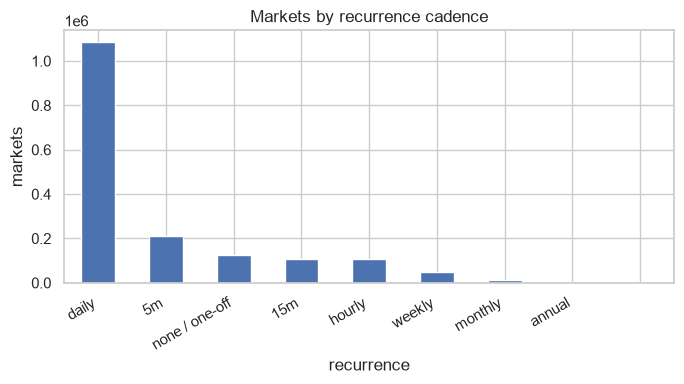

recurrence
daily             1083365
5m                 210617
none / one-off     127356
15m                106455
hourly             105667
weekly              49874
monthly             12834
annual               2522
                      177
Name: count, dtype: int64

In [8]:
recurrence_counts = all_df["recurrence"].fillna("none / one-off").value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
recurrence_counts.plot(kind="bar", ax=ax)
ax.set_title("Markets by recurrence cadence")
ax.set_ylabel("markets")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

recurrence_counts


## 6. Which coins dominate?

The coin identity lives at the series level (`ticker`), not on the individual market --
we already pulled it out into a `coin` column when loading the data.

**Caveat:** `coin` is parsed with a naive `ticker.split("-")[0]` heuristic, which works
well for the crypto "coin-multi-strikes-hourly" tickers it was designed for, but misfires
on other markets whose tickers don't follow that shape (`league`, `counter`, `us`, `atp`
in the list below aren't coins -- they're sports/politics tickers getting caught by the
same split). Treat non-crypto entries here as noise, not signal -- `src/filtering/keyword_filter.py`
is the real crypto classifier; this is just a quick look at the raw, unfiltered data.

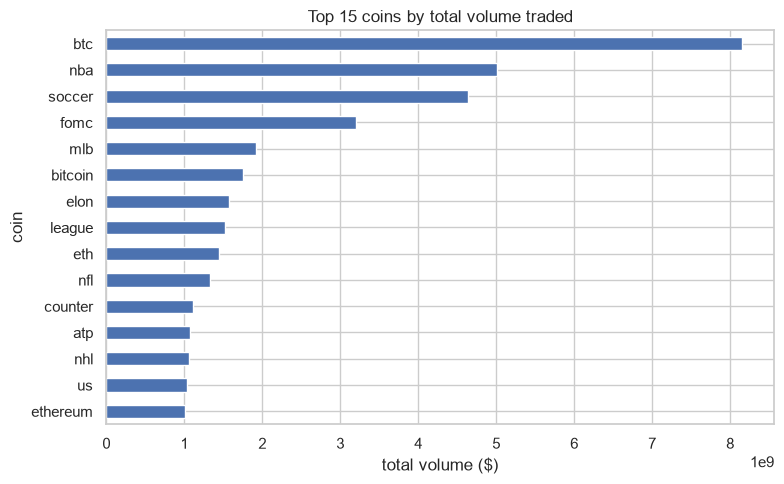

coin
btc         8.154524e+09
nba         5.005307e+09
soccer      4.641323e+09
fomc        3.199199e+09
mlb         1.921460e+09
bitcoin     1.747033e+09
elon        1.569992e+09
league      1.520064e+09
eth         1.446291e+09
nfl         1.327182e+09
counter     1.107840e+09
atp         1.070080e+09
nhl         1.058550e+09
us          1.038929e+09
ethereum    1.008717e+09
Name: volumeNum, dtype: float64

In [9]:
top_coins = (
    all_df.dropna(subset=["coin"])
          .groupby("coin")["volumeNum"].sum()
          .sort_values(ascending=False)
          .head(15)
)

fig, ax = plt.subplots(figsize=(8, 5))
top_coins.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 15 coins by total volume traded")
ax.set_xlabel("total volume ($)")
plt.tight_layout()
plt.show()

top_coins


## 7. Engagement and how contested markets are

`commentCount` (social engagement, from the event) and `competitive` (Polymarket's own
closeness-to-50/50 score, from the market) are two very different signals worth a quick
look side by side.

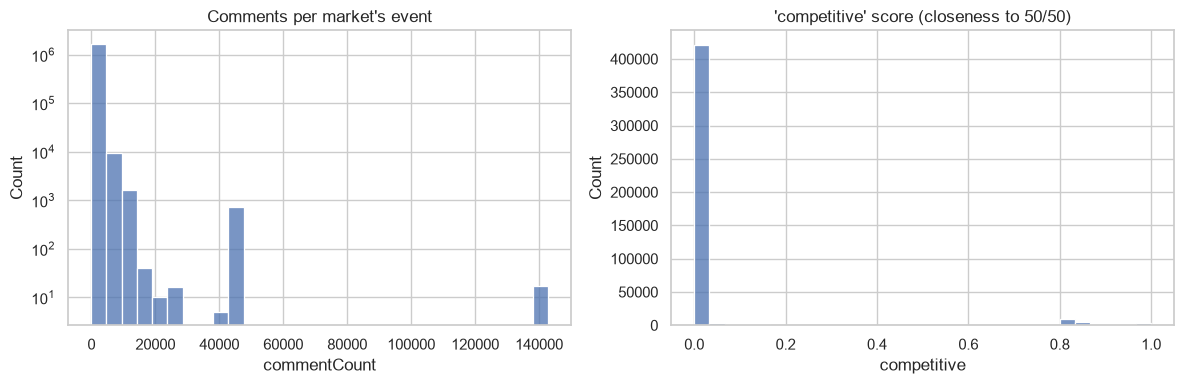

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(all_df["commentCount"].dropna(), bins=30, ax=axes[0])
axes[0].set_title("Comments per market's event")
axes[0].set_yscale("log")

sns.histplot(all_df["competitive"].dropna(), bins=30, ax=axes[1])
axes[1].set_title("'competitive' score (closeness to 50/50)")

plt.tight_layout()
plt.show()


## 8. How long do markets stay open?

Time from `createdAt` to `closedTime`, for markets that have actually closed. A few
outliers (data issues, or markets left open far past their end date) get trimmed from
the plot so they don't flatten the rest of the histogram.

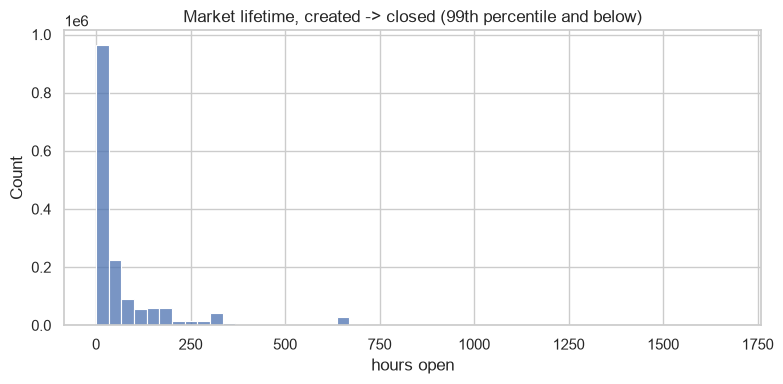

count    1.655139e+06
mean     1.288911e+02
std      4.342550e+02
min      3.563209e-02
25%      2.360196e+01
50%      2.415631e+01
75%      8.062136e+01
max      2.490092e+04
dtype: float64

In [11]:
lifetime_hours = (all_df["closedTime"] - all_df["createdAt"]).dt.total_seconds() / 3600
lifetime_hours = lifetime_hours.dropna()
lifetime_hours = lifetime_hours[lifetime_hours > 0]

trimmed = lifetime_hours[lifetime_hours < lifetime_hours.quantile(0.99)]

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(trimmed, bins=50, ax=ax)
ax.set_title("Market lifetime, created -> closed (99th percentile and below)")
ax.set_xlabel("hours open")
plt.tight_layout()
plt.show()

lifetime_hours.describe()
